# 🔎 LightGBM Parameter Discovery
**Semi-Automated Classification Workflow**

Supported use cases:
- Customer Churn Prediction
- Credit Risk Prediction
- Loan Default Prediction

> **Goal:** Discover several promising LightGBM parameter combinations to use later in Hyperparameter Tuning.

> This notebook does **not** perform final tuning — it explores the search space and helps you understand the trade-offs between candidates.

---

## Section 1 — Import Libraries

Load required libraries.

In [ ]:
!pip install -q lightgbm imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              roc_curve, ConfusionMatrixDisplay)

from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Section 2 — Upload Dataset

Upload the cleaned dataset from the previous notebook.

In [ ]:
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print(f'File loaded: {filename}')
print(f'Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns')

Saving clean_dataset.csv to clean_dataset.csv
File loaded: clean_dataset.csv
Dataset Shape: 7021 rows x 20 columns


---
## Section 3 — Select Features

Write the selected features from the Baseline Benchmark notebook, and define the target column.

In [ ]:
selected_features = [
    'InternetService',
    'PaymentMethod',
    'tenure',
    'Contract',
    'MonthlyCharges',
    'TotalCharges',
    'MultipleLines',
    'StreamingTV',
    'StreamingMovies',
    'PhoneService'
]

target_column = 'Churn'

print(f'Selected Features ({len(selected_features)}): {selected_features}')
print(f'Target Column: {target_column}')

Selected Features (10): ['InternetService', 'PaymentMethod', 'tenure', 'Contract', 'MonthlyCharges', 'TotalCharges', 'MultipleLines', 'StreamingTV', 'StreamingMovies', 'PhoneService']
Target Column: Churn


---
## Section 4 — Split Feature and Target

Create X and y.

In [ ]:
X = df[selected_features]
y = df[target_column]

print(f'X Shape: {X.shape}')
print(f'y Shape: {y.shape}')

X Shape: (7021, 10)
y Shape: (7021,)


---
## Section 5 — Encode Categorical Features

Binary categories use Label Encoding. Multi-category columns use One-Hot Encoding.

In [ ]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
binary_cols = []
multi_cols = []

for col in categorical_cols:
    if X[col].nunique() == 2:
        binary_cols.append(col)
    else:
        multi_cols.append(col)

le = LabelEncoder()
for col in binary_cols:
    X[col] = le.fit_transform(X[col].astype(str))

if multi_cols:
    X = pd.get_dummies(X, columns=multi_cols, drop_first=True)

if y.dtype == 'object':
    y = le.fit_transform(y.astype(str))
    y = pd.Series(y)

print(f'Binary Encoded Columns: {binary_cols}')
print(f'One-Hot Encoded Columns: {multi_cols}')
print(f'Total Features After Encoding: {X.shape[1]}')

Binary Encoded Columns: ['PhoneService']
One-Hot Encoded Columns: ['InternetService', 'PaymentMethod', 'Contract', 'MultipleLines', 'StreamingTV', 'StreamingMovies']
Total Features After Encoding: 17


---
## Section 6 — Train Test Split

Split the dataset into 80% training and 20% testing.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train Shape: {X_train.shape}')
print(f'Test Shape: {X_test.shape}')

Train Shape: (5616, 17)
Test Shape: (1405, 17)


---
## Section 7 — Check Target Balance

Display the class distribution of the training data.

,Class,Count,Percentage (%)
0,0,4131,73.557692
1,1,1485,26.442308


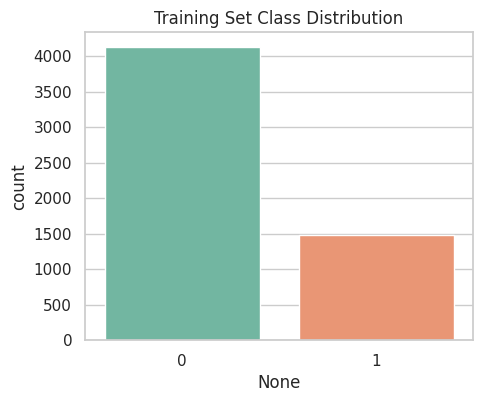

In [ ]:
counts = y_train.value_counts()
percentages = y_train.value_counts(normalize=True) * 100

balance_df = pd.DataFrame({
    'Class': counts.index,
    'Count': counts.values,
    'Percentage (%)': percentages.values
})

display(balance_df)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=y_train, ax=ax, palette='Set2')
ax.set_title('Training Set Class Distribution')
plt.show()

min_pct = percentages.min()
IS_IMBALANCED = min_pct < 30

---
## Section 8 — Apply SMOTE

SMOTE is applied automatically only if the training data is imbalanced.

In [ ]:
smote_applied = 'No'

if IS_IMBALANCED:
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    y_train = pd.Series(y_train)
    smote_applied = 'Yes'
    print('SMOTE applied. New training shape:', X_train.shape)
else:
    print('SMOTE skipped.')

SMOTE applied. New training shape: (8262, 17)


---
## Section 9 — Explain LightGBM Parameters

Before searching, understand what each parameter controls.

In [ ]:
param_explained = pd.DataFrame({
    'Parameter': ['learning_rate', 'n_estimators', 'num_leaves', 'max_depth',
                  'min_child_samples', 'subsample', 'colsample_bytree',
                  'reg_alpha', 'reg_lambda'],
    'Purpose': ['Controls how fast the model learns',
                'Number of boosting trees to build',
                'Controls tree complexity',
                'Limits how deep each tree can grow',
                'Minimum data needed in a leaf',
                'Fraction of rows used per tree',
                'Fraction of columns used per tree',
                'L1 regularization to reduce overfitting',
                'L2 regularization to reduce overfitting'],
    'Search Range': ['[0.01, 0.03, 0.05, 0.1]',
                      '[100, 200, 300, 500]',
                      '[15, 31, 50, 70]',
                      '[-1, 5, 7, 10]',
                      '[10, 20, 30, 50]',
                      '[0.7, 0.8, 0.9, 1.0]',
                      '[0.7, 0.8, 0.9, 1.0]',
                      '[0, 0.01, 0.1, 1]',
                      '[0, 0.01, 0.1, 1]']
})

display(param_explained)

,Parameter,Purpose,Search Range
0,learning_rate,Controls how fast the model learns,"[0.01, 0.03, 0.05, 0.1]"
1,n_estimators,Number of boosting trees to build,"[100, 200, 300, 500]"
2,num_leaves,Controls tree complexity,"[15, 31, 50, 70]"
3,max_depth,Limits how deep each tree can grow,"[-1, 5, 7, 10]"
4,min_child_samples,Minimum data needed in a leaf,"[10, 20, 30, 50]"
5,subsample,Fraction of rows used per tree,"[0.7, 0.8, 0.9, 1.0]"
6,colsample_bytree,Fraction of columns used per tree,"[0.7, 0.8, 0.9, 1.0]"
7,reg_alpha,L1 regularization to reduce overfitting,"[0, 0.01, 0.1, 1]"
8,reg_lambda,L2 regularization to reduce overfitting,"[0, 0.01, 0.1, 1]"


---
## Section 10 — Define Parameter Search Space

Set the search space used by RandomizedSearchCV.

In [ ]:
param_dist = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [100, 200, 300, 500],
    'num_leaves': [15, 31, 50, 70],
    'max_depth': [-1, 5, 7, 10],
    'min_child_samples': [10, 20, 30, 50],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0, 0.01, 0.1, 1]
}

print('Parameter search space ready.')

Parameter search space ready.


---
## Section 11 — RandomizedSearchCV

Search the parameter space using cross-validation and ROC AUC scoring.

In [ ]:
lgbm = LGBMClassifier(random_state=42, verbose=-1)

random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print('Search complete.')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Search complete.


---
## Section 12 — Evaluate Every Candidate

Instead of stopping at the single best estimator, evaluate every tested parameter combination on the test set.

In [ ]:
all_params = random_search.cv_results_['params']

candidate_results = []

for params in all_params:
    model = LGBMClassifier(random_state=42, verbose=-1, **params)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    candidate_results.append({
        'ROC AUC': roc_auc_score(y_test, proba),
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred),
        'Parameter Set': params
    })

candidates_df = pd.DataFrame(candidate_results)
candidates_df = candidates_df.sort_values('ROC AUC', ascending=False).reset_index(drop=True)
candidates_df.insert(0, 'Rank', range(1, len(candidates_df) + 1))

for col in ['ROC AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score']:
    candidates_df[col] = candidates_df[col].round(4)

top10 = candidates_df.head(10)

print('Top 10 Candidates (sorted by ROC AUC):')
display(top10)

Top 10 Candidates (sorted by ROC AUC):


,Rank,ROC AUC,Accuracy,Precision,Recall,F1 Score,Parameter Set
0,1,0.8362,0.7794,0.5724,0.6586,0.6125,"{'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alp..."
1,2,0.8360,0.7794,0.5674,0.7016,0.6274,"{'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha..."
2,3,0.8356,0.7772,0.5684,0.6586,0.6102,"{'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha..."
3,4,0.8353,0.7765,0.5653,0.6747,0.6152,"{'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alp..."
4,5,0.8352,0.7794,0.5711,0.6694,0.6163,"{'subsample': 0.7, 'reg_lambda': 0.01, 'reg_al..."
5,6,0.8349,0.7765,0.5617,0.7097,0.6271,"{'subsample': 0.8, 'reg_lambda': 0.01, 'reg_al..."
6,7,0.8345,0.7786,0.5682,0.6828,0.6203,"{'subsample': 0.9, 'reg_lambda': 0, 'reg_alpha..."
7,8,0.8344,0.7808,0.5727,0.6774,0.6207,"{'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha..."
8,9,0.8339,0.7765,0.5659,0.6694,0.6133,"{'subsample': 0.8, 'reg_lambda': 0.01, 'reg_al..."
9,10,0.8338,0.7744,0.5589,0.7016,0.6222,"{'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alp..."


---
## Section 13 — Compare Candidates

A higher ROC AUC does not always mean a better F1 Score or Recall. Compare the top candidates against the baseline.

In [ ]:
# ✏️ Set the ROC AUC from your Baseline Benchmark notebook
baseline_roc_auc = 0.80

compare_df = top10[['Rank', 'ROC AUC', 'F1 Score', 'Recall', 'Precision']].copy()
compare_df['Improvement from Baseline'] = (compare_df['ROC AUC'] - baseline_roc_auc).round(4)

display(compare_df)

,Rank,ROC AUC,F1 Score,Recall,Precision,Improvement from Baseline
0,1,0.8362,0.6125,0.6586,0.5724,0.0362
1,2,0.8360,0.6274,0.7016,0.5674,0.0360
2,3,0.8356,0.6102,0.6586,0.5684,0.0356
3,4,0.8353,0.6152,0.6747,0.5653,0.0353
4,5,0.8352,0.6163,0.6694,0.5711,0.0352
5,6,0.8349,0.6271,0.7097,0.5617,0.0349
6,7,0.8345,0.6203,0.6828,0.5682,0.0345
7,8,0.8344,0.6207,0.6774,0.5727,0.0344
8,9,0.8339,0.6133,0.6694,0.5659,0.0339
9,10,0.8338,0.6222,0.7016,0.5589,0.0338


---
## Section 14 — Recommended Parameter

Rank 1 is not always chosen automatically. If another candidate has a very similar ROC AUC but a clearly better F1 Score, it is recommended instead.

In [ ]:
rank1 = top10.iloc[0]
recommended = rank1
reason = 'Rank 1 has the highest ROC AUC and is selected as the recommended candidate.'

for i in range(1, len(top10)):
    candidate = top10.iloc[i]
    roc_diff = rank1['ROC AUC'] - candidate['ROC AUC']

    if roc_diff < 0.005 and candidate['F1 Score'] > rank1['F1 Score']:
        recommended = candidate
        reason = (f'Rank {int(candidate["Rank"])} has a slightly lower ROC AUC '
                   f'but provides a better F1 Score than Rank 1.')
        break

recommended_params = recommended['Parameter Set']

print('=' * 50)
print('        RECOMMENDED PARAMETER')
print('=' * 50)
print(f'Recommended Rank : {int(recommended["Rank"])}')
print(f'Reason           : {reason}')
print(f'Selected Parameters:')
for param, value in recommended_params.items():
    print(f'  {param}: {value}')
print('=' * 50)

        RECOMMENDED PARAMETER
Recommended Rank : 2
Reason           : Rank 2 has a slightly lower ROC AUC but provides a better F1 Score than Rank 1.
Selected Parameters:
  subsample: 0.8
  reg_lambda: 0
  reg_alpha: 0
  num_leaves: 15
  n_estimators: 500
  min_child_samples: 10
  max_depth: -1
  learning_rate: 0.01
  colsample_bytree: 0.7


---
## Section 15 — Evaluate Recommended Model

Train and evaluate the recommended parameter set on the test set.

In [ ]:
final_model = LGBMClassifier(random_state=42, verbose=-1, **recommended_params)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

final_accuracy = accuracy_score(y_test, y_pred)
final_precision = precision_score(y_test, y_pred)
final_recall = recall_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred)
final_roc_auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy : {final_accuracy:.4f}')
print(f'Precision: {final_precision:.4f}')
print(f'Recall   : {final_recall:.4f}')
print(f'F1 Score : {final_f1:.4f}')
print(f'ROC AUC  : {final_roc_auc:.4f}')

Accuracy : 0.7794
Precision: 0.5674
Recall   : 0.7016
F1 Score : 0.6274
ROC AUC  : 0.8360


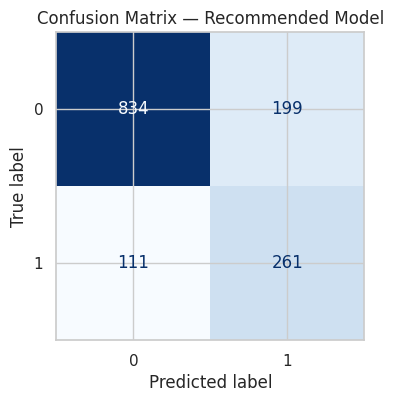

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Recommended Model')
plt.show()

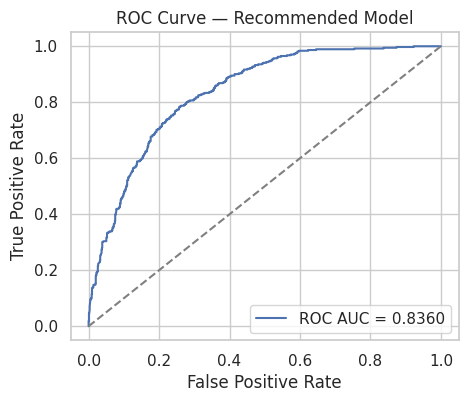

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, label=f'ROC AUC = {final_roc_auc:.4f}')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Recommended Model')
ax.legend()
plt.show()

---
## Section 16 — Final Summary

A complete summary of the parameter discovery process.

In [ ]:
print('=' * 52)
print('             FINAL SUMMARY')
print('=' * 52)
print(f'Dataset Shape               : {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Selected Features           : {selected_features}')
print(f'Total Features              : {X.shape[1]}')
print(f'Encoding Applied            : Label + One-Hot')
print(f'SMOTE Applied                : {smote_applied}')
print(f'Random Search Candidates    : {len(candidates_df)}')
print(f'Top ROC AUC                  : {top10.iloc[0]["ROC AUC"]}')
print()
print(f'Recommended Candidate        : Rank {int(recommended["Rank"])}')
print(f'Recommended ROC AUC          : {final_roc_auc:.4f}')
print(f'Recommended F1               : {final_f1:.4f}')
print(f'Recommended Recall           : {final_recall:.4f}')
print(f'Recommended Precision        : {final_precision:.4f}')
print()
print('Selected Parameters:')
for param, value in recommended_params.items():
    print(f'  {param}: {value}')
print('=' * 52)

             FINAL SUMMARY
Dataset Shape               : 7021 rows x 20 columns
Selected Features           : ['InternetService', 'PaymentMethod', 'tenure', 'Contract', 'MonthlyCharges', 'TotalCharges', 'MultipleLines', 'StreamingTV', 'StreamingMovies', 'PhoneService']
Total Features              : 17
Encoding Applied            : Label + One-Hot
SMOTE Applied                : Yes
Random Search Candidates    : 50
Top ROC AUC                  : 0.8362

Recommended Candidate        : Rank 2
Recommended ROC AUC          : 0.8360
Recommended F1               : 0.6274
Recommended Recall           : 0.7016
Recommended Precision        : 0.5674

Selected Parameters:
  subsample: 0.8
  reg_lambda: 0
  reg_alpha: 0
  num_leaves: 15
  n_estimators: 500
  min_child_samples: 10
  max_depth: -1
  learning_rate: 0.01
  colsample_bytree: 0.7


---
## Section 17 — Learning Notes

- Random Search does not always produce the best business model.
- The highest ROC AUC is not always the most balanced model.
- Always compare multiple evaluation metrics before making a final decision.

✅ **Next Step:** Use these discovered parameters as a starting point for the Hyperparameter Tuning notebook.